In [1]:
# ── Imports ───────────────────────────────────────────────────────────────────
!pip install transformers datasets
!pip install sentencepiece tiktoken
import os
import logging
import csv
from datetime import datetime
import json

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from transformers import AutoModel, AutoTokenizer, DataCollatorWithPadding
from datasets import load_dataset, DatasetDict
from torch.utils.data import DataLoader
from tqdm import tqdm
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, accuracy_score

from transformers import get_linear_schedule_with_warmup


In [2]:
CHECKPOINT_PATH = "best_model.pt"
DEVICE          = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EMOTION_LABELS = [
    "admiration", "amusement", "anger", "annoyance", "approval",
    "caring", "confusion", "curiosity", "desire", "disappointment",
    "disapproval", "disgust", "embarrassment", "excitement", "fear",
    "gratitude", "grief", "joy", "love", "nervousness", "optimism",
    "pride", "realization", "relief", "remorse", "sadness",
    "surprise", "neutral",
]

In [3]:
# ── Logging setup ─────────────────────────────────────────────────────────────
os.makedirs("logs", exist_ok=True)
log_filename = datetime.now().strftime("logs/train_%Y-%m-%d_%H-%M-%S.txt")

logging.basicConfig(
    level=logging.INFO,
    format="[%(asctime)s][%(name)s][%(levelname)s] - %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
    handlers=[
        logging.FileHandler(log_filename),
        logging.StreamHandler(),
    ],
)
logger = logging.getLogger(__name__)
logger.info("Logging initialised -> %s", log_filename)

[2026-04-06 18:08:30][__main__][INFO] - Logging initialised -> logs/train_2026-04-06_18-08-30.txt


In [4]:
# ── Dataset ───────────────────────────────────────────────────────────────────
ds = load_dataset("google-research-datasets/go_emotions", "raw")

print(f"Train size: {len(ds['train'])}")
ds_sample = ds['train'][0]
for key, val in ds_sample.items():
    print(f"  {key}: {val}")

[2026-04-06 18:08:33][httpx][INFO] - HTTP Request: HEAD https://huggingface.co/datasets/google-research-datasets/go_emotions/resolve/main/README.md "HTTP/1.1 307 Temporary Redirect"
[2026-04-06 18:08:33][httpx][INFO] - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/datasets/google-research-datasets/go_emotions/add492243ff905527e67aeb8b80c082af02207c3/README.md "HTTP/1.1 200 OK"
[2026-04-06 18:08:33][httpx][INFO] - HTTP Request: HEAD https://huggingface.co/datasets/google-research-datasets/go_emotions/resolve/add492243ff905527e67aeb8b80c082af02207c3/go_emotions.py "HTTP/1.1 404 Not Found"
[2026-04-06 18:08:33][httpx][INFO] - HTTP Request: HEAD https://s3.amazonaws.com/datasets.huggingface.co/datasets/datasets/google-research-datasets/go_emotions/google-research-datasets/go_emotions.py "HTTP/1.1 404 Not Found"
[2026-04-06 18:08:34][httpx][INFO] - HTTP Request: GET https://huggingface.co/api/datasets/google-research-datasets/go_emotions/revision/add492243ff905527e67aeb8b80c08

Train size: 211225
  text: That game hurt.
  id: eew5j0j
  author: Brdd9
  subreddit: nrl
  link_id: t3_ajis4z
  parent_id: t1_eew18eq
  created_utc: 1548381056.0
  rater_id: 1
  example_very_unclear: False
  admiration: 0
  amusement: 0
  anger: 0
  annoyance: 0
  approval: 0
  caring: 0
  confusion: 0
  curiosity: 0
  desire: 0
  disappointment: 0
  disapproval: 0
  disgust: 0
  embarrassment: 0
  excitement: 0
  fear: 0
  gratitude: 0
  grief: 0
  joy: 0
  love: 0
  nervousness: 0
  optimism: 0
  pride: 0
  realization: 0
  relief: 0
  remorse: 0
  sadness: 1
  surprise: 0
  neutral: 0


In [5]:
# ── Model definition ──────────────────────────────────────────────────────────
class EmotionClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.checkpoint = "microsoft/deberta-v3-small"
        self.tokenizer = AutoTokenizer.from_pretrained(self.checkpoint)

        self.basemodel = AutoModel.from_pretrained(self.checkpoint)
        self.head = nn.Sequential(
            nn.Linear(self.basemodel.config.hidden_size, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(256, 28),
        )
    def tokenize_function(self, examples):
        return self.tokenizer(
            examples['text'],
            truncation=True,
            padding="max_length",
            max_length=128,
        )

    def forward(self, input_ids, attention_mask, labels=None):
        outputs = self.basemodel(input_ids=input_ids, attention_mask=attention_mask)
        last_hidden_state = outputs.last_hidden_state

        # Mean pooling
        pooled = (
            (last_hidden_state * attention_mask.unsqueeze(-1)).sum(1)
            / attention_mask.sum(1, keepdim=True)
        )
        logits = self.head(pooled)

        if labels is not None:
            loss_fn = nn.BCEWithLogitsLoss()
            loss = loss_fn(logits, labels.float())
            return loss, logits

        return logits

In [6]:
# ── Tokenise & build label column ─────────────────────────────────────────────
emotion_labels = EMOTION_LABELS

device = DEVICE
logger.info("Using device: %s", device)

model = EmotionClassifier().to(device).float()

ds = ds.map(model.tokenize_function, batched=True)

def preprocess(example):
    return {"labels": [example[lbl] for lbl in emotion_labels]}

ds = ds.map(preprocess)
ds = ds.remove_columns([
    "text", "id", "author", "subreddit", "link_id", "parent_id",
    "created_utc", "rater_id", "example_very_unclear",
] + emotion_labels)

[2026-04-06 18:08:43][__main__][INFO] - Using device: cuda
[2026-04-06 18:08:43][httpx][INFO] - HTTP Request: HEAD https://huggingface.co/microsoft/deberta-v3-small/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
[2026-04-06 18:08:43][httpx][INFO] - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/microsoft/deberta-v3-small/a36c739020e01763fe789b4b85e2df55d6180012/config.json "HTTP/1.1 200 OK"
[2026-04-06 18:08:43][httpx][INFO] - HTTP Request: HEAD https://huggingface.co/microsoft/deberta-v3-small/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
[2026-04-06 18:08:43][httpx][INFO] - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/microsoft/deberta-v3-small/a36c739020e01763fe789b4b85e2df55d6180012/tokenizer_config.json "HTTP/1.1 200 OK"
[2026-04-06 18:08:44][httpx][INFO] - HTTP Request: GET https://huggingface.co/api/models/microsoft/deberta-v3-small/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
[2026-04-06 18:08:45][httpx][INFO] - HTTP Request: G

Map:   0%|          | 0/211225 [00:00<?, ? examples/s]

Map:   0%|          | 0/211225 [00:00<?, ? examples/s]

In [7]:
# ── Train / val / test split ──────────────────────────────────────────────────
split_1 = ds['train'].train_test_split(test_size=0.2, seed=42)
split_2 = split_1['test'].train_test_split(test_size=0.5, seed=42)

ds = DatasetDict({
    "train":      split_1['train'],
    "validation": split_2['train'],
    "test":       split_2['test'],
})

logger.info(
    "Split sizes -- train: %d  val: %d  test: %d",
    len(ds['train']), len(ds['validation']), len(ds['test']),
)

[2026-04-06 18:10:39][__main__][INFO] - Split sizes -- train: 168980  val: 21122  test: 21123


In [8]:
all_labels_np = np.array([example["labels"] for example in ds['train']])
pos_counts = all_labels_np.sum(axis=0)

for label, count in sorted(zip(emotion_labels, pos_counts), key=lambda x: x[1]):
    print(f"{label:<20} {int(count):>6}  ({100*count/len(ds['train']):.2f}%)")

grief                   516  (0.31%)
relief                 1028  (0.61%)
pride                  1031  (0.61%)
nervousness            1454  (0.86%)
embarrassment          2001  (1.18%)
remorse                2047  (1.21%)
fear                   2579  (1.53%)
desire                 3012  (1.78%)
disgust                4216  (2.49%)
surprise               4442  (2.63%)
excitement             4505  (2.67%)
caring                 4770  (2.82%)
sadness                5412  (3.20%)
confusion              5873  (3.48%)
joy                    6382  (3.78%)
anger                  6477  (3.83%)
love                   6534  (3.87%)
disappointment         6841  (4.05%)
optimism               6992  (4.14%)
realization            7010  (4.15%)
amusement              7341  (4.34%)
curiosity              7735  (4.58%)
disapproval            9240  (5.47%)
gratitude              9297  (5.50%)
annoyance             10912  (6.46%)
admiration            13715  (8.12%)
approval              14106  (8.35%)
n

In [9]:
# ── DataLoaders ───────────────────────────────────────────────────────────────
collator = DataCollatorWithPadding(tokenizer=model.tokenizer, return_tensors="pt")

train_dl = DataLoader(
    ds['train'], batch_size=64, shuffle=True,
    collate_fn=collator, pin_memory=True, num_workers=2,
)

val_dl = DataLoader(
    ds['validation'], batch_size=64, shuffle=False,
    collate_fn=collator, pin_memory=True, num_workers=2,
)

test_dl = DataLoader(
    ds['test'], batch_size=32, shuffle=False,
    collate_fn=collator, num_workers=2,
)


In [10]:
NUM_EPOCHS = 5
THRESHOLD  = 0.5


# ── Class-balanced pos_weights (fixed) ────────────────────────────────────────
neg_counts  = all_labels_np.shape[0] - pos_counts

pos_weights = torch.tensor(
    np.sqrt(neg_counts / (pos_counts + 1e-8)),   # ✅ softened weights
    dtype=torch.float32
).to(device)

torch.set_printoptions(sci_mode=False)

loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weights)


# ── Optimizer ────────────────────────────────────────────────────────────────
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)


# ── Scheduler ────────────────────────────────────────────────────────────────
total_steps   = NUM_EPOCHS * len(train_dl)
warmup_steps  = total_steps // 10  # 10% warmup

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

In [11]:
print(pos_weights)

tensor([ 3.3646,  4.6924,  5.0089,  3.8060,  3.3135,  5.8673,  5.2699,  4.5658,
         7.4231,  4.8684,  4.1579,  6.2515,  9.1350,  6.0423,  8.0325,  4.1444,
        18.0688,  5.0475,  4.9861, 10.7339,  4.8133, 12.7632,  4.8068, 12.7819,
         9.0305,  5.4976,  6.0862,  1.6797], device='cuda:0')


In [12]:
# ── Training loop ─────────────────────────────────────────────────────────────

# Per-epoch accumulators
train_metrics_per_epoch = []   # (loss, acc, prec, rec, f1)
val_metrics_per_epoch   = []

# Per-batch CSV
os.makedirs("metrics", exist_ok=True)
batch_csv_path = datetime.now().strftime("metrics/batch_metrics_%Y-%m-%d_%H-%M-%S.csv")
batch_csv_file = open(batch_csv_path, "w", newline="")
batch_writer   = csv.DictWriter(
    batch_csv_file,
    fieldnames=["epoch", "phase", "batch_idx", "loss", "acc", "precision", "recall", "f1"],
)
batch_writer.writeheader()
logger.info("Batch metrics CSV -> %s", batch_csv_path)

best_val_f1 = 0.0

for epoch in range(NUM_EPOCHS):

    # ── TRAIN ──────────────────────────────────────────────────────────────
    model.train()
    train_loss_accum = train_prec_accum = train_rec_accum = train_f1_accum = train_acc_accum = 0.0

    loop = tqdm(train_dl, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train]")
    for batch_idx, batch in enumerate(loop):
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["labels"].to(device).float()

        logits = model(input_ids=input_ids, attention_mask=attention_mask)
        loss   = loss_fn(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        probs     = torch.sigmoid(logits)
        preds     = (probs > THRESHOLD).float()
        preds_np  = preds.detach().cpu().numpy()
        labels_np = labels.detach().cpu().numpy()

        batch_prec = precision_score(labels_np, preds_np, average='macro', zero_division=0)
        batch_rec  = recall_score(labels_np, preds_np, average='macro', zero_division=0)
        batch_f1   = f1_score(labels_np, preds_np, average='macro', zero_division=0)
        batch_acc  = (preds == labels).float().mean().item()
        batch_loss = loss.item()

        train_loss_accum += batch_loss
        train_prec_accum += batch_prec
        train_rec_accum  += batch_rec
        train_f1_accum   += batch_f1
        train_acc_accum  += batch_acc

        loop.set_postfix(
            loss=f"{batch_loss:.4f}", acc=f"{batch_acc:.4f}",
            f1=f"{batch_f1:.4f}", prec=f"{batch_prec:.4f}", rec=f"{batch_rec:.4f}",
        )
        batch_writer.writerow({
            "epoch": epoch + 1, "phase": "train", "batch_idx": batch_idx,
            "loss": round(batch_loss, 6), "acc": round(batch_acc, 6),
            "precision": round(batch_prec, 6), "recall": round(batch_rec, 6),
            "f1": round(batch_f1, 6),
        })

    n_train = len(train_dl)
    train_loss_epoch = train_loss_accum / n_train
    train_acc_epoch  = train_acc_accum  / n_train
    train_prec_epoch = train_prec_accum / n_train
    train_rec_epoch  = train_rec_accum  / n_train
    train_f1_epoch   = train_f1_accum   / n_train

    # ── VALIDATION ─────────────────────────────────────────────────────────
    model.eval()
    val_loss_accum = val_prec_accum = val_rec_accum = val_f1_accum = val_acc_accum = 0.0

    with torch.no_grad():
        for batch_idx, batch in enumerate(tqdm(val_dl, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Val]")):
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels         = batch["labels"].to(device).float()

            logits = model(input_ids=input_ids, attention_mask=attention_mask)
            loss   = loss_fn(logits, labels)

            probs     = torch.sigmoid(logits)
            preds     = (probs > THRESHOLD).float()
            preds_np  = preds.detach().cpu().numpy()
            labels_np = labels.detach().cpu().numpy()

            batch_prec = precision_score(labels_np, preds_np, average='macro', zero_division=0)
            batch_rec  = recall_score(labels_np, preds_np, average='macro', zero_division=0)
            batch_f1   = f1_score(labels_np, preds_np, average='macro', zero_division=0)
            batch_acc  = (preds == labels).float().mean().item()
            batch_loss = loss.item()

            val_loss_accum += batch_loss
            val_prec_accum += batch_prec
            val_rec_accum  += batch_rec
            val_f1_accum   += batch_f1
            val_acc_accum  += batch_acc

            batch_writer.writerow({
                "epoch": epoch + 1, "phase": "val", "batch_idx": batch_idx,
                "loss": round(batch_loss, 6), "acc": round(batch_acc, 6),
                "precision": round(batch_prec, 6), "recall": round(batch_rec, 6),
                "f1": round(batch_f1, 6),
            })

    n_val = len(val_dl)
    val_loss_epoch = val_loss_accum / n_val
    val_acc_epoch  = val_acc_accum  / n_val
    val_prec_epoch = val_prec_accum / n_val
    val_rec_epoch  = val_rec_accum  / n_val
    val_f1_epoch   = val_f1_accum   / n_val

    # ── Epoch summary ───────────────────────────────────────────────────────
    train_metrics_per_epoch.append((train_loss_epoch, train_acc_epoch, train_prec_epoch, train_rec_epoch, train_f1_epoch))
    val_metrics_per_epoch.append((val_loss_epoch, val_acc_epoch, val_prec_epoch, val_rec_epoch, val_f1_epoch))

    summary = (
        f"Epoch {epoch+1}/{NUM_EPOCHS} | "
        f"Train  loss={train_loss_epoch:.4f}  acc={train_acc_epoch:.4f}  "
        f"prec={train_prec_epoch:.4f}  rec={train_rec_epoch:.4f}  f1={train_f1_epoch:.4f} | "
        f"Val    loss={val_loss_epoch:.4f}  acc={val_acc_epoch:.4f}  "
        f"prec={val_prec_epoch:.4f}  rec={val_rec_epoch:.4f}  f1={val_f1_epoch:.4f}"
    )
    print(f"\n{summary}")
    logger.info(summary)

    # ── Save best model ─────────────────────────────────────────────────────
    if val_f1_epoch > best_val_f1:
        best_val_f1 = val_f1_epoch
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        logger.info("Best model saved (val f1=%.4f)", best_val_f1)
        print("Best model saved!")

batch_csv_file.close()
logger.info("Training complete. Batch metrics saved to %s", batch_csv_path)

[2026-04-06 18:11:30][__main__][INFO] - Batch metrics CSV -> metrics/batch_metrics_2026-04-06_18-11-30.csv
Epoch 1/5 [Val]: 100%|██████████| 331/331 [00:50<00:00,  6.59it/s]
[2026-04-06 18:32:29][__main__][INFO] - Epoch 1/5 | Train  loss=0.4255  acc=0.9376  prec=0.1930  rec=0.2043  f1=0.1773 | Val    loss=0.3357  acc=0.9495  prec=0.2883  rec=0.3319  f1=0.2814



Epoch 1/5 | Train  loss=0.4255  acc=0.9376  prec=0.1930  rec=0.2043  f1=0.1773 | Val    loss=0.3357  acc=0.9495  prec=0.2883  rec=0.3319  f1=0.2814


[2026-04-06 18:32:30][__main__][INFO] - Best model saved (val f1=0.2814)


Best model saved!


Epoch 2/5 [Val]: 100%|██████████| 331/331 [00:50<00:00,  6.60it/s]
[2026-04-06 18:53:30][__main__][INFO] - Epoch 2/5 | Train  loss=0.3274  acc=0.9491  prec=0.2960  rec=0.3370  f1=0.2897 | Val    loss=0.3140  acc=0.9481  prec=0.3022  rec=0.3660  f1=0.3052


...

Best model saved!


Epoch 5/5 [Val]: 100%|██████████| 331/331 [00:50<00:00,  6.60it/s]
[2026-04-06 19:56:34][__main__][INFO] - Epoch 5/5 | Train  loss=0.2873  acc=0.9484  prec=0.3234  rec=0.4086  f1=0.3352 | Val    loss=0.3050  acc=0.9444  prec=0.2975  rec=0.3959  f1=0.3130



Epoch 5/5 | Train  loss=0.2873  acc=0.9484  prec=0.3234  rec=0.4086  f1=0.3352 | Val    loss=0.3050  acc=0.9444  prec=0.2975  rec=0.3959  f1=0.3130


[2026-04-06 19:56:35][__main__][INFO] - Best model saved (val f1=0.3130)
[2026-04-06 19:56:35][__main__][INFO] - Training complete. Batch metrics saved to metrics/batch_metrics_2026-04-06_18-11-30.csv


Best model saved!


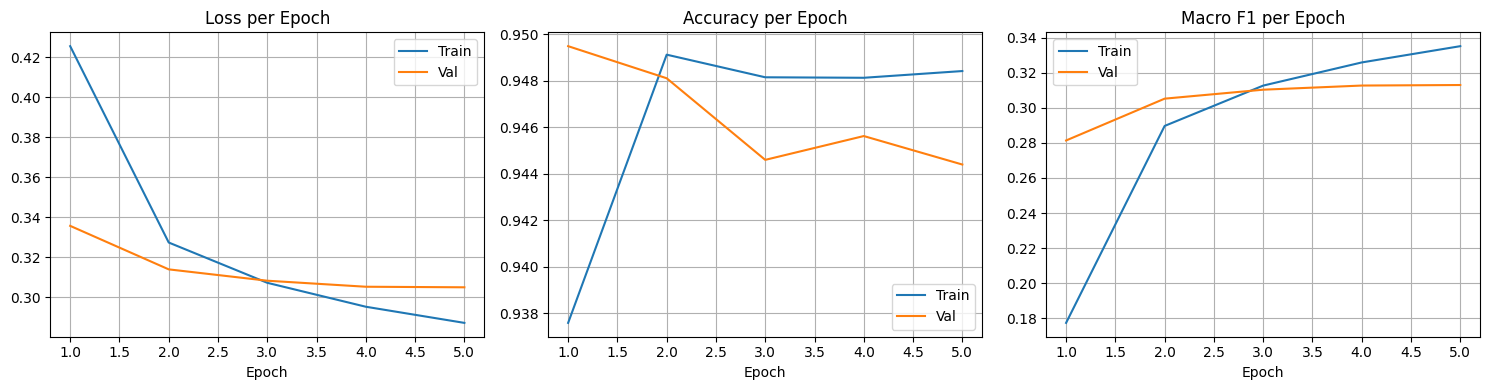

In [13]:
# ── Epoch-level plots ─────────────────────────────────────────────────────────
epochs = range(1, len(train_metrics_per_epoch) + 1)

train_losses = [m[0] for m in train_metrics_per_epoch]
val_losses   = [m[0] for m in val_metrics_per_epoch]
train_accs   = [m[1] for m in train_metrics_per_epoch]
val_accs     = [m[1] for m in val_metrics_per_epoch]
train_f1s    = [m[4] for m in train_metrics_per_epoch]
val_f1s      = [m[4] for m in val_metrics_per_epoch]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(epochs, train_losses, label="Train")
axes[0].plot(epochs, val_losses, label="Val")
axes[0].set_title("Loss per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid()

axes[1].plot(epochs, train_accs, label="Train")
axes[1].plot(epochs, val_accs, label="Val")
axes[1].set_title("Accuracy per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid()

axes[2].plot(epochs, train_f1s, label="Train")
axes[2].plot(epochs, val_f1s, label="Val")
axes[2].set_title("Macro F1 per Epoch")
axes[2].set_xlabel("Epoch")
axes[2].legend()
axes[2].grid()

plt.tight_layout()
plt.show()

In [14]:

model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE))

<All keys matched successfully>

In [16]:
# ── Function: Optimize thresholds per class ─────────────────────────
def optimize_thresholds(probs, labels, thresholds=np.arange(0.1, 0.9, 0.02)):
    n_classes = labels.shape[1]
    best_thresholds = np.zeros(n_classes)

    print("\n--- Optimizing thresholds per class ---")
    for label_idx in tqdm(range(n_classes), desc="Classes", leave=False):
        best_t, best_f1 = 0.5, 0.0
        for t in thresholds:
            preds = (probs[:, label_idx] > t).astype(int)
            f1 = f1_score(labels[:, label_idx], preds, zero_division=0)
            if f1 > best_f1:
                best_f1 = f1
                best_t = t
        best_thresholds[label_idx] = best_t
        print(f"{emotion_labels[label_idx]:<20} threshold={best_t:.2f}  f1={best_f1:.4f}")
    print("--- Threshold optimization complete ---\n")
    return best_thresholds

# ── Section: Compute train probabilities ──────────────────────────
logger.info("=== Computing train probabilities for threshold optimization ===")


model.eval()
all_probs_val, all_labels_val = [], []

with torch.no_grad():
    for batch in tqdm(val_dl, desc="Val batches"):
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["labels"].to(device).float()

        logits = model(input_ids=input_ids, attention_mask=attention_mask)
        probs  = torch.sigmoid(logits).cpu().numpy()

        all_probs_val.append(probs)
        all_labels_val.append(labels.cpu().numpy())

all_probs_val  = np.vstack(all_probs_val)
all_labels_val = np.vstack(all_labels_val)
logger.info("Validation probabilities computed: %d samples", len(all_probs_val))

# ── Section: Optimize thresholds ───────────────────────────────────
best_thresholds = optimize_thresholds(all_probs_val, all_labels_val)
print("\nOptimized thresholds for all classes:")
for i, t in enumerate(best_thresholds):
    print(f"{emotion_labels[i]:<20} -> {t:.2f}")

# ── Section: Compute test probabilities ───────────────────────────
logger.info("=== Computing test probabilities ===")

all_probs_test, all_labels_test = [], []

with torch.no_grad():
    for batch in tqdm(test_dl, desc="Test batches"):
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["labels"].to(device).float()

        logits = model(input_ids=input_ids, attention_mask=attention_mask)
        probs  = torch.sigmoid(logits).cpu().numpy()

        all_probs_test.append(probs)
        all_labels_test.append(labels.cpu().numpy())

all_probs_test       = np.vstack(all_probs_test)
all_labels_test      = np.vstack(all_labels_test)
logger.info("Test probabilities computed: %d samples", len(all_probs_test))

# ── Section: Evaluate with static threshold ───────────────────────
logger.info("=== Evaluating test set with static threshold=0.5 ===")
all_preds_static  = (all_probs_test > 0.5).astype(int)
logger.info("Static threshold evaluation complete -- %d samples", len(all_preds_static))

# ── Section: Evaluate with optimized thresholds ───────────────────
logger.info("=== Evaluating test set with optimized thresholds ===")
all_preds_optimized = (all_probs_test > best_thresholds).astype(int)
logger.info("Optimized threshold evaluation complete -- %d samples", len(all_preds_optimized))

[2026-04-06 20:06:28][__main__][INFO] - === Computing train probabilities for threshold optimization ===
Val batches: 100%|██████████| 331/331 [00:48<00:00,  6.77it/s]
[2026-04-06 20:07:17][__main__][INFO] - Validation probabilities computed: 21122 samples



--- Optimizing thresholds per class ---


Classes:   4%|▎         | 1/28 [00:00<00:14,  1.88it/s]

admiration           threshold=0.64  f1=0.5828


Classes:   7%|▋         | 2/28 [00:01<00:13,  1.95it/s]

...

Classes:  96%|█████████▋| 27/28 [00:13<00:00,  1.98it/s]

surprise             threshold=0.66  f1=0.4369


[2026-04-06 20:07:31][__main__][INFO] - === Computing test probabilities ===


neutral              threshold=0.34  f1=0.5472
--- Threshold optimization complete ---


Optimized thresholds for all classes:
admiration           -> 0.64
amusement            -> 0.70
anger                -> 0.56
annoyance            -> 0.42
approval             -> 0.34
caring               -> 0.56
confusion            -> 0.50
curiosity            -> 0.54
desire               -> 0.66
disappointment       -> 0.44
disapproval          -> 0.42
disgust              -> 0.56
embarrassment        -> 0.74
excitement           -> 0.56
fear                 -> 0.82
gratitude            -> 0.82
grief                -> 0.64
joy                  -> 0.56
love                 -> 0.60
nervousness          -> 0.62
optimism             -> 0.64
pride                -> 0.74
realization          -> 0.32
relief               -> 0.46
remorse              -> 0.78
sadness              -> 0.66
surprise             -> 0.66
neutral              -> 0.34


Test batches: 100%|██████████| 661/661 [00:46<00:00, 14.14it/s]
[2026-04-06 20:08:17][__main__][INFO] - Test probabilities computed: 21123 samples
[2026-04-06 20:08:17][__main__][INFO] - === Evaluating test set with static threshold=0.5 ===
[2026-04-06 20:08:17][__main__][INFO] - Static threshold evaluation complete -- 21123 samples
[2026-04-06 20:08:17][__main__][INFO] - === Evaluating test set with optimized thresholds ===
[2026-04-06 20:08:17][__main__][INFO] - Optimized threshold evaluation complete -- 21123 samples


In [17]:
print("Static F1:", f1_score(all_labels_test, all_preds_static, average='macro', zero_division=0))
print("Optimized F1:", f1_score(all_labels_test, all_preds_optimized, average='macro', zero_division=0))

Static F1: 0.3759691994799232
Optimized F1: 0.389257561166965


In [18]:
def save_thresholds(thresholds, labels, prefix="optim_thresholds"):
    timestamp = datetime.now().strftime("%Y%m%d-%H%M%S")
    filename = f"{prefix}_{timestamp}.json"

    data = {
        "timestamp": timestamp,
        "thresholds": {
            labels[i]: float(thresholds[i]) for i in range(len(labels))
        }
    }

    with open(filename, "w") as f:
        json.dump(data, f, indent=4)

    print(f"\nSaved thresholds → {filename}")
    return filename

In [19]:
def results_table(all_labels_test, all_preds_test):
    print(f"\n{'Label':<22} {'Prec':>6} {'Rec':>6} {'F1':>6} {'Acc':>6} {'Support':>8}")
    print("-" * 64)

    per_class_acc = []

    for i, lbl in enumerate(EMOTION_LABELS):
        y_true = all_labels_test[:, i]
        y_pred = all_preds_test[:, i]

        p = precision_score(y_true, y_pred, zero_division=0)
        r = recall_score(y_true, y_pred, zero_division=0)
        f = f1_score(y_true, y_pred, zero_division=0)
        acc = accuracy_score(y_true, y_pred)
        support = int(y_true.sum())

        per_class_acc.append(acc)

        print(f"{lbl:<22} {p:>6.3f} {r:>6.3f} {f:>6.3f} {acc:>6.3f} {support:>8}")

    # Macro metrics
    macro_p = precision_score(all_labels_test, all_preds_test, average='macro', zero_division=0)
    macro_r = recall_score(all_labels_test, all_preds_test, average='macro', zero_division=0)
    macro_f = f1_score(all_labels_test, all_preds_test, average='macro', zero_division=0)
    macro_acc = np.mean(per_class_acc)

    print("-" * 64)
    print(f"{'MACRO':<22} {macro_p:>6.3f} {macro_r:>6.3f} {macro_f:>6.3f} {macro_acc:>6.3f}")

    logger.info(
        "Eval complete -- macro prec=%.4f rec=%.4f f1=%.4f acc=%.4f",
        macro_p, macro_r, macro_f, macro_acc
)

In [20]:
print("Static threshold results")
results_table(all_labels_test, all_preds_static)

Static threshold results

Label                    Prec    Rec     F1    Acc  Support
----------------------------------------------------------------
admiration              0.486  0.714  0.578  0.918     1665
amusement               0.516  0.800  0.627  0.958      938
anger                   0.299  0.558  0.390  0.936      771
annoyance               0.255  0.323  0.285  0.898     1324
approval                0.333  0.218  0.263  0.899     1754
caring                  0.286  0.512  0.367  0.946      640
confusion               0.292  0.533  0.377  0.937      752
curiosity               0.341  0.731  0.465  0.925      943
desire                  0.298  0.474  0.366  0.969      401
disappointment          0.227  0.257  0.241  0.939      794
disapproval             0.276  0.388  0.323  0.919     1058
disgust                 0.263  0.437  0.329  0.951      581
embarrassment           0.198  0.340  0.250  0.976      244
excitement              0.264  0.405  0.320  0.953      571
fear     

[2026-04-06 20:14:00][__main__][INFO] - Eval complete -- macro prec=0.3194 rec=0.4881 f1=0.3760 acc=0.9443


----------------------------------------------------------------
MACRO                   0.319  0.488  0.376  0.944


In [22]:
print("Optimised threshold results")
results_table(all_labels_test, all_preds_optimized)

Optimised threshold results

Label                    Prec    Rec     F1    Acc  Support
----------------------------------------------------------------
admiration              0.568  0.617  0.592  0.933     1665
amusement               0.557  0.712  0.625  0.962      938
anger                   0.331  0.508  0.401  0.944      771
annoyance               0.222  0.459  0.300  0.866     1324
approval                0.236  0.424  0.303  0.838     1754
caring                  0.308  0.469  0.372  0.952      640
confusion               0.292  0.533  0.377  0.937      752
curiosity               0.347  0.689  0.462  0.928      943
desire                  0.404  0.377  0.390  0.978      401
disappointment          0.196  0.324  0.244  0.925      794
disapproval             0.237  0.466  0.314  0.898     1058
disgust                 0.296  0.373  0.331  0.958      581
embarrassment           0.323  0.213  0.257  0.986      244
excitement              0.287  0.349  0.315  0.959      571
fear  

[2026-04-06 20:15:15][__main__][INFO] - Eval complete -- macro prec=0.3541 rec=0.4605 f1=0.3893 acc=0.9415


----------------------------------------------------------------
MACRO                   0.354  0.461  0.389  0.941


In [26]:
# ── Sample predictions ────────────────────────────────────────────────────────
for i in range(1000, 1015):
    sample    = ds['test'][i]
    text      = model.tokenizer.decode(sample["input_ids"], skip_special_tokens=True)
    true_idxs = np.where(all_labels_test[i] == 1)[0]
    pred_idxs = np.where(all_preds_optimized[i] == 1)[0]
    print(f"\nTEXT : {text}")
    print(f"TRUE : {[emotion_labels[j] for j in true_idxs]}")
    print(f"PRED : {[emotion_labels[j] for j in pred_idxs]}")


TEXT : Predatory towing is getting ridiculous. I have up to date stickers for all the properties I maintain and have been towed twice. Fuck em.
TRUE : ['disgust']
PRED : ['anger', 'annoyance', 'disgust']

TEXT : It makes me mad when people steal them lol... chances are if you're nice I'll just *give* it to you
TRUE : ['amusement']
PRED : ['amusement', 'annoyance']

TEXT : Why does everyone hate the creme brûlées? They’re easily my favorite.
TRUE : ['pride']
PRED : ['love']

TEXT : Heh, U.S. only has a partial government right now :/
TRUE : ['sadness']
PRED : ['neutral']

TEXT : > Corporate Media I like this one.
TRUE : ['love']
PRED : ['love']

TEXT : Finally! Somebody who legitimately hates planet Jupiter!
TRUE : ['relief']
PRED : ['realization', 'relief', 'neutral']

TEXT : Good job, white truck! Don't use the damn shoulder to pass!
TRUE : ['admiration']
PRED : ['admiration']

TEXT : That's an extremely ignorant thing to say
TRUE : ['disapproval']
PRED : ['annoyance', 'disapproval']